In [1]:
from pandas import DataFrame,read_csv
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
import warnings
warnings.filterwarnings("ignore")

import joblib

In [2]:
df = read_csv("data/Life Expectancy Data.csv")

df.columns = df.columns.str.strip().str.replace(" ", "_")

In [3]:
df.head()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
df.tail()

,Country,Year,Status,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,...,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
2933,Zimbabwe,2004,Developing,44.3,723.0,27,4.36,0.0,68.0,31,...,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,Zimbabwe,2003,Developing,44.5,715.0,26,4.06,0.0,7.0,998,...,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,Zimbabwe,2002,Developing,44.8,73.0,25,4.43,0.0,73.0,304,...,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,Zimbabwe,2001,Developing,45.3,686.0,25,1.72,0.0,76.0,529,...,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8
2937,Zimbabwe,2000,Developing,46.0,665.0,24,1.68,0.0,79.0,1483,...,78.0,7.10,78.0,43.5,547.358878,12222251.0,11.0,11.2,0.434,9.8


In [5]:
df.shape

(2938, 22)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life_expectancy                  2928 non-null   float64
 4   Adult_Mortality                  2928 non-null   float64
 5   infant_deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage_expenditure           2938 non-null   float64
 8   Hepatitis_B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five_deaths                2938 non-null   int64  
 12  Polio                          

In [ ]:
df.describe()

,Year,Life_expectancy,Adult_Mortality,infant_deaths,Alcohol,percentage_expenditure,Hepatitis_B,Measles,BMI,under-five_deaths,Polio,Total_expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness__1-19_years,thinness_5-9_years,Income_composition_of_resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [9]:
print(df.isna().sum())
print(df.isna().sum().sum())

Country                              0
Year                                 0
Status                               0
Life_expectancy                     10
Adult_Mortality                     10
infant_deaths                        0
Alcohol                            194
percentage_expenditure               0
Hepatitis_B                        553
Measles                              0
BMI                                 34
under-five_deaths                    0
Polio                               19
Total_expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness__1-19_years                34
thinness_5-9_years                  34
Income_composition_of_resources    167
Schooling                          163
dtype: int64
2563


In [10]:
df["Life_expectancy"].isna().sum()

np.int64(10)

In [11]:
df.dropna(subset=["Life_expectancy"],inplace=True)

In [12]:
df.duplicated().sum()

np.int64(0)

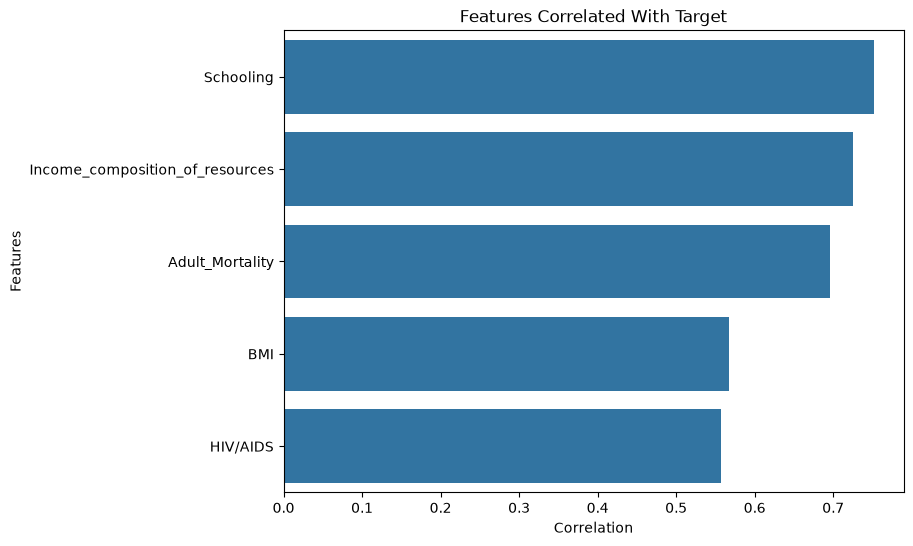

In [14]:
plt.figure(figsize=(8, 6))

corr = (df.corr(numeric_only=True)["Life_expectancy"].drop("Life_expectancy").abs().sort_values(ascending=False).head())

sns.barplot(x=corr.values,y=corr.index)

plt.title("Features Correlated With Target")
plt.xlabel("Correlation")
plt.ylabel("Features")
plt.savefig(f"images/Absolute_Corralation.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

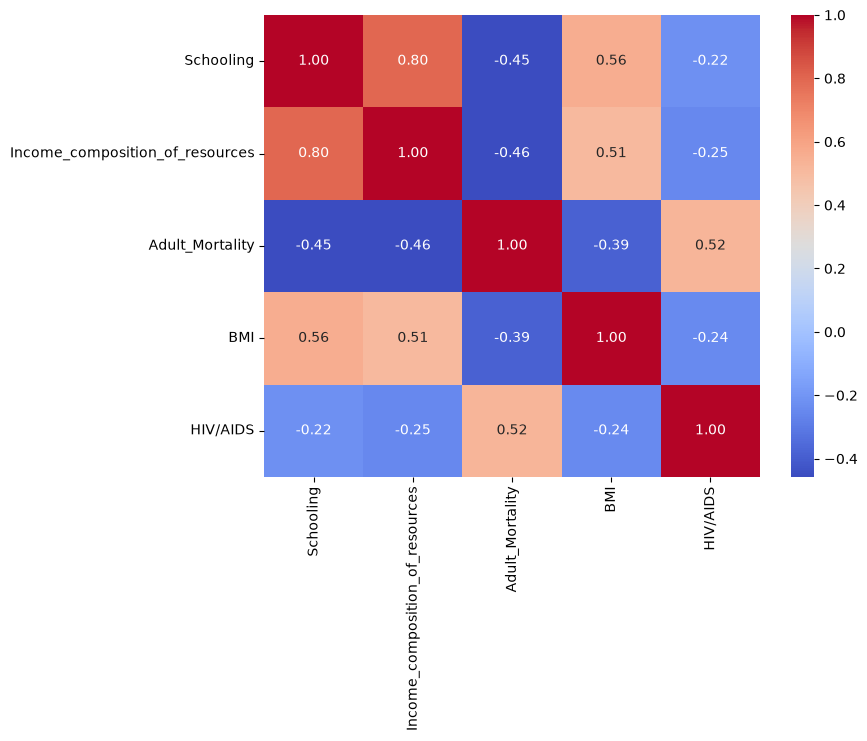

In [15]:
plt.figure(figsize=(8,6))

top = ["Schooling","Income_composition_of_resources","Adult_Mortality","BMI","HIV/AIDS"]

sns.heatmap(df[top].corr(),annot=True,cmap="coolwarm",fmt=".2f")
plt.savefig(f"images/HeatMap.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

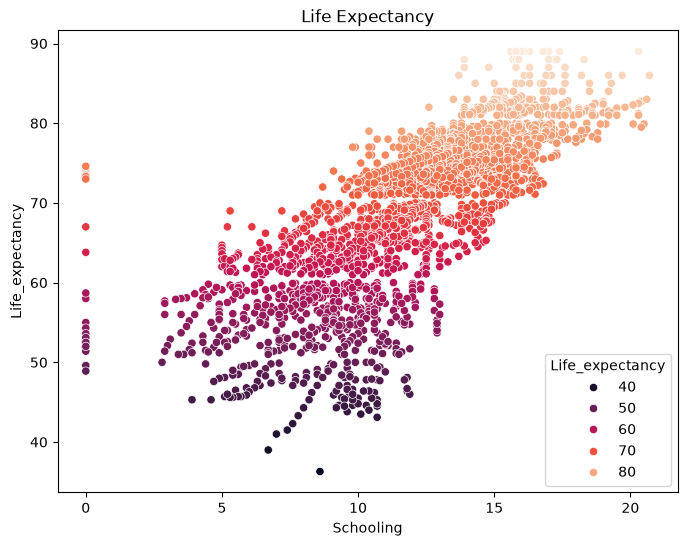

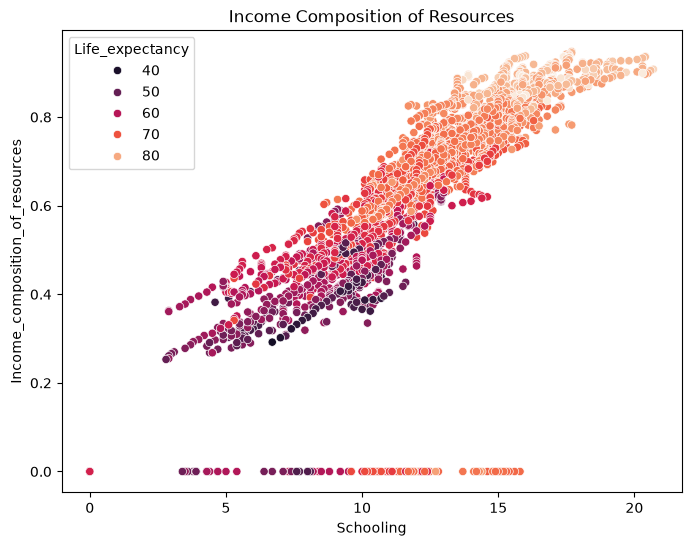

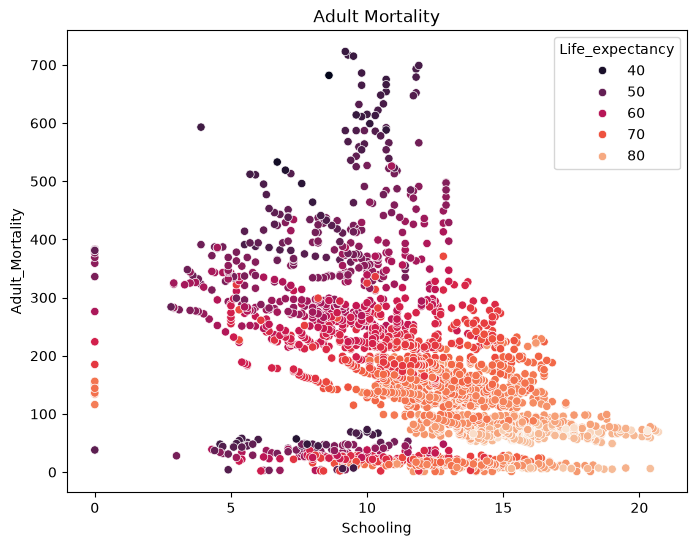

In [16]:
col_scat = {
    "Life_expectancy":"Life Expectancy",
    "Income_composition_of_resources":"Income Composition of Resources",
    "Adult_Mortality":"Adult Mortality"
}

for col,ti in col_scat.items():
    plt.figure(figsize=(8,6))
    sns.scatterplot(df,x="Schooling",y=col,palette="rocket",hue="Life_expectancy")
    plt.title(ti)
    plt.savefig(f"images/ScatterPlot_of_{ti}.png",
        dpi=300,
        bbox_inches="tight")
    plt.show()


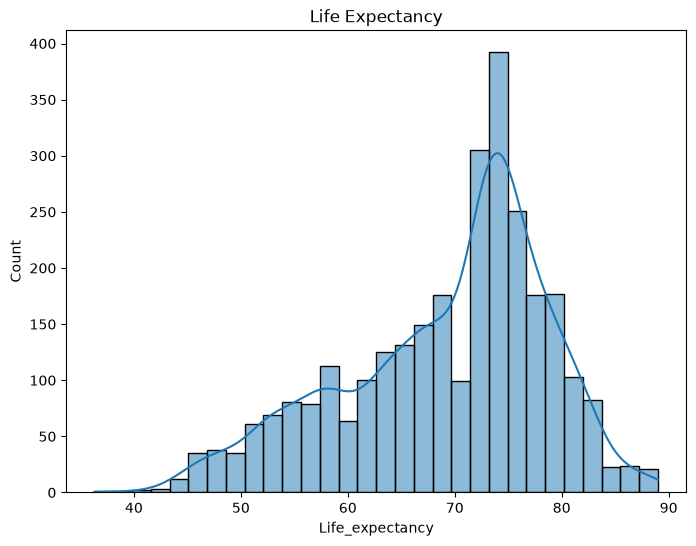

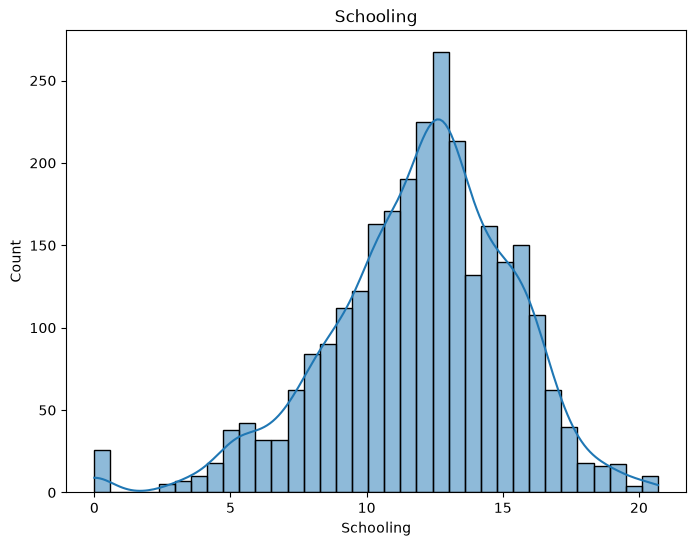

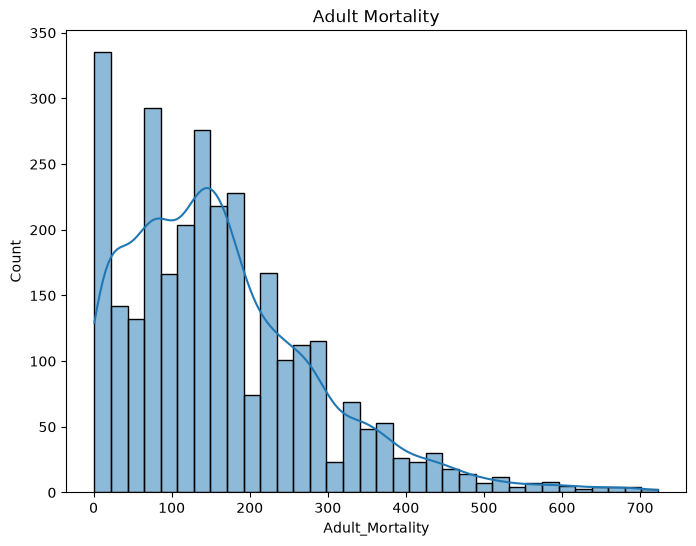

In [18]:
col_hist = {
    "Life_expectancy":"Life Expectancy",
    "Schooling":"Schooling",
    "Adult_Mortality":"Adult Mortality"
}
for col,ti in col_hist.items():
    plt.figure(figsize=(8,6))
    sns.histplot(df,x=col,kde=True)
    plt.title(ti)
    plt.savefig(f"images/HistPlot_of_{ti}.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()

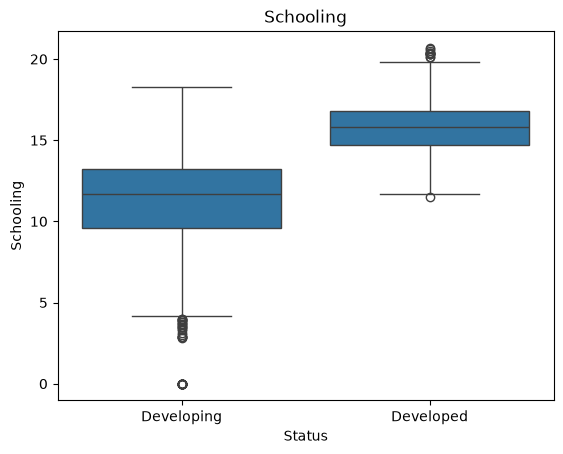

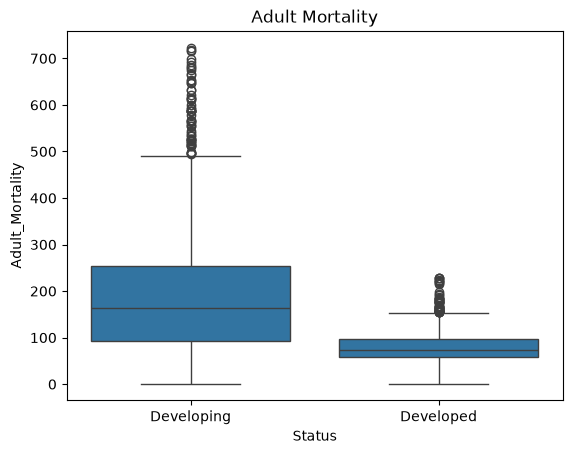

In [21]:
col_box = {
    "Schooling":"Schooling",
    "Adult_Mortality":"Adult Mortality"
}

for col,ti in col_box.items():
    sns.boxplot(df,x="Status",y=col)
    plt.title(ti)
    plt.savefig(f"images/BoxPlot_of_{ti}.png",
            dpi=300,
            bbox_inches="tight")
    plt.show()

Status
Developing    2416
Developed      512
Name: count, dtype: int64
-------------------------------------------------------------------------------------


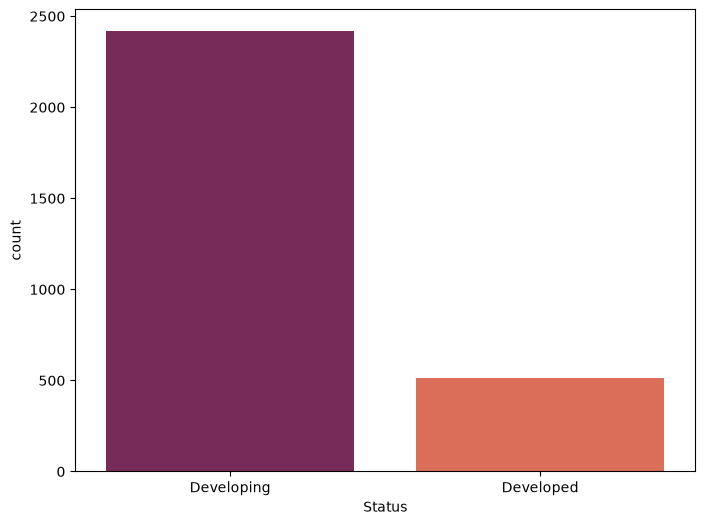

In [22]:
print(df["Status"].value_counts())
print("-"*85)
plt.figure(figsize=(8,6))
sns.countplot(df,x="Status",palette="rocket",legend=False,hue="Status")
plt.savefig(f"images/CountPlot.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [23]:
X,y = df.drop("Life_expectancy",axis=1),df["Life_expectancy"]

x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

categorical = X.select_dtypes(include="str").columns
numerical = X.select_dtypes(include="number").columns

In [24]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())]),numerical),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))]), categorical)])

In [25]:
pipe = Pipeline([("prep",preprocessor),("model",LinearRegression())])

In [26]:
param = [

    {
        "prep__num__scaler":[StandardScaler(),RobustScaler()],
        "model": [LinearRegression()],
        "model__fit_intercept": [True, False],
        "model__positive": [True, False]
    },

    {
        "prep__num__scaler":["passthrough"],
        "model": [RandomForestRegressor()],
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": [1.0, "sqrt", "log2"]
    },

    {
        "prep__num__scaler":["passthrough"],
        "model": [GradientBoostingRegressor()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [2, 3, 5],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__subsample": [0.8, 1.0]
    },

    {
        "prep__num__scaler":["passthrough"],
        "model": [XGBRegressor()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7],
        "model__min_child_weight": [1, 3, 5],
        "model__subsample": [0.8, 1.0],
        "model__colsample_bytree": [0.8, 1.0]
    }
]

In [27]:
grid = RandomizedSearchCV(pipe,param,n_iter=50,cv=5,verbose=1,n_jobs=-1,scoring="neg_root_mean_squared_error")

In [28]:
grid.fit(x_train,y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","[{'model': [LinearRegression()], 'model__fit_intercept': [True, False], 'model__positive': [True, False], 'prep__num__scaler': [StandardScaler(), RobustScaler()]}, {'model': [RandomForestRegressor()], 'model__max_depth': [None, 5, ...], 'model__max_features': [1.0, 'sqrt', ...], 'model__min_samples_leaf': [1, 2, ...], ...}, ...]"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` an

In [29]:
print(grid.best_estimator_)
print("-"*50)
print(grid.best_params_)
print("-"*50)
print(abs(grid.best_score_))

best = grid.best_estimator_

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   'passthrough')]),
                                                  Index(['Year', 'Adult_Mortality', 'infant_deaths', 'Alcohol',
       'percentage_expenditure', 'Hepatitis_B', 'Measles', 'BMI',
       'under-five_deaths', 'Polio', 'Total_expenditure', 'Diphtheria',
       'HIV/AIDS', 'GDP', 'Populat...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                        

In [30]:
y_pred = best.predict(x_test)

mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

p = {
    "MAE_score":mae,
    "MSE_score":mse,
    "RMSE_score":rmse,
    "R2_score":r2
}

p = DataFrame(p,index=[""])
p

,MAE_score,MSE_score,RMSE_score,R2_score
,1.03668,2.660873,1.631218,0.96991


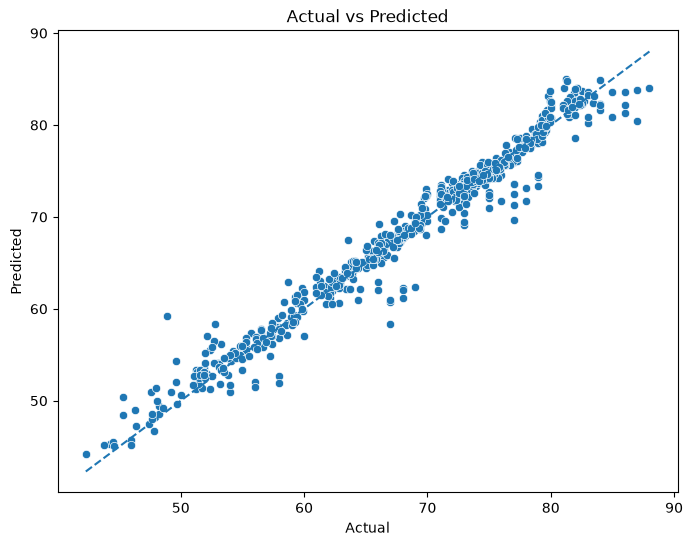

In [31]:
plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_test,y=y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")

plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],linestyle="--")
plt.savefig(f"images/diff_actual_vs_predict.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

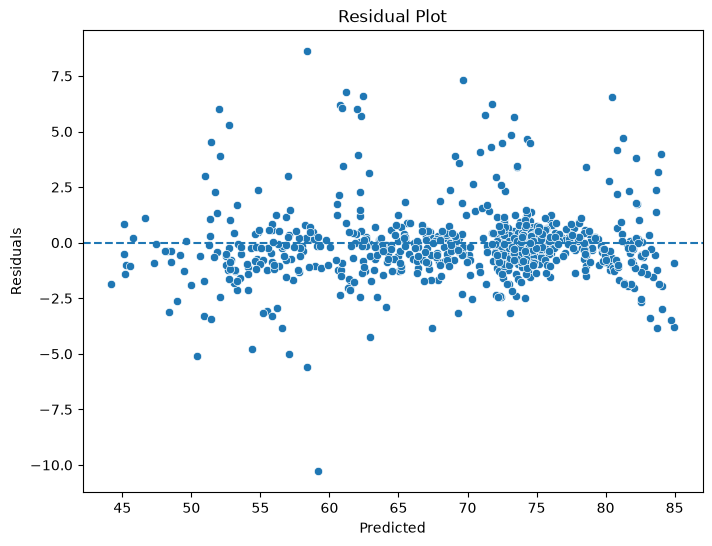

In [32]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

sns.scatterplot(x=y_pred,y=residuals)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.savefig(f"images/Residual_Actual_vs_Pridicted.png",
        dpi=300,
        bbox_inches="tight")
plt.show()

In [33]:
joblib.dump(grid.best_estimator_,"models/Life_Expectancy_model.joblib")
print("model saved")

model saved
